In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
pd.set_option('display.max_columns', None)

In [24]:
df=pd.read_csv(r'D:\vs code projects\rental_analysis\data\interim\Gurugram\flat_house_data_missing_value_imputation.csv')

In [25]:
df

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,supertech araville,sector 79,0.71,5521.0,2,2,0,9.0,Under Construction,1295.0,0,0,0,0,0,0,0
1,flat,supertech araville,sector 79,0.95,6209.0,2,2,3,7.0,New Property,1385.0,1,0,0,0,0,0,49
2,flat,ireo skyon,sector 60,2.65,13125.0,3,4,3+,7.0,Moderately Old,2037.0,0,1,0,0,0,1,152
3,flat,bhemerlei,sohna road,0.69,5100.0,2,2,2,3.0,Under Construction,1350.0,0,0,0,0,0,0,0
4,flat,tata gurgaon gateway,sector 113,2.45,10788.0,3,3,3,8.0,Relatively New,2014.0,0,0,0,0,0,0,110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3650,flat,godrej aria,sector 79,0.95,6552.0,2,2,3,5.0,Relatively New,1611.0,0,0,0,0,0,1,174
3651,flat,m3m one key resiments,sector 67,0.80,13115.0,1,1,0,0.0,Relatively New,610.0,0,0,0,0,0,0,0
3652,house,independent,sector 50,10.56,32593.0,5,5,3,3.0,Moderately Old,3240.0,0,1,0,0,0,0,20
3653,flat,godrej oasis,sector 88a,1.38,6680.0,3,3,3+,7.0,Relatively New,2296.0,0,1,0,0,0,0,72


<Axes: ylabel='luxury_score'>

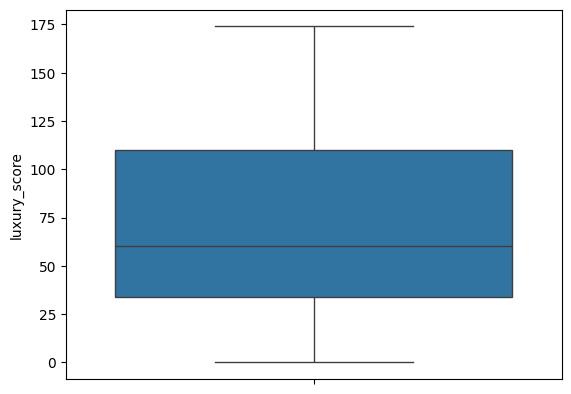

In [26]:
sns.boxplot(df['luxury_score'])

In [27]:
train_df = df.drop(columns=['society','price_per_sqft'])

In [28]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None 

In [29]:

train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

<Axes: ylabel='floorNum'>

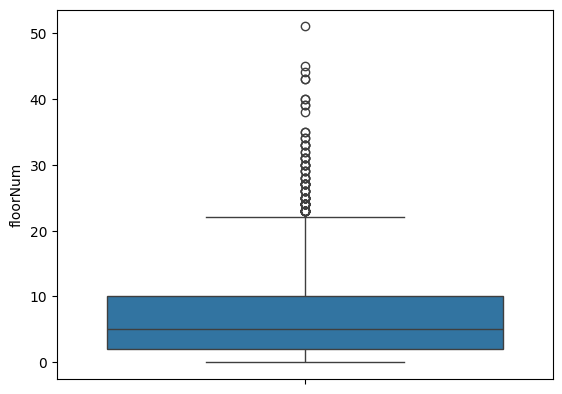

In [30]:
sns.boxplot(df['floorNum'])

In [31]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None

In [32]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [33]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [34]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'new',
       'new sector 2', 'sector 1', 'sector 102', 'sector 103',
       'sector 104', 'sector 105', 'sector 106', 'sector 107',
       'sector 108', 'sector 109', 'sector 10a', 'sector 11',
       'sector 110', 'sector 111', 'sector 112', 'sector 113',
       'sector 12', 'sector 13', 'sector 14', 'sector 15', 'sector 17',
       'sector 17a', 'sector 17b', 'sector 2', 'sector 21', 'sector 22',
       'sector 23', 'sector 24', 'sector 25', 'sector 26', 'sector 27',
       'sector 28', 'sector 3', 'sector 3 phase 2',
       'sector 3 phase 3 extension', 'sector 30', 'sector 31',
       'sector 33', 'sector 36', 'sector 36a', 'sector 37c', 'sector 37d',
       'sector 38', 'sector 39', 'sector 4', 'sector 40', 'sector 41',
       'sector 43', 'sector 45', 'sector 46', 'sector 47', 'sector 48',
       'sector 49', 'sector 5', 'sector 50', 'sector 51', 'sector 52',
       'sector 53', 'sect

C:\Users\msi 1\AppData\Local\Temp\ipykernel_21252\848989002.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_df.select_dtypes(include=['object']).columns


<Axes: >

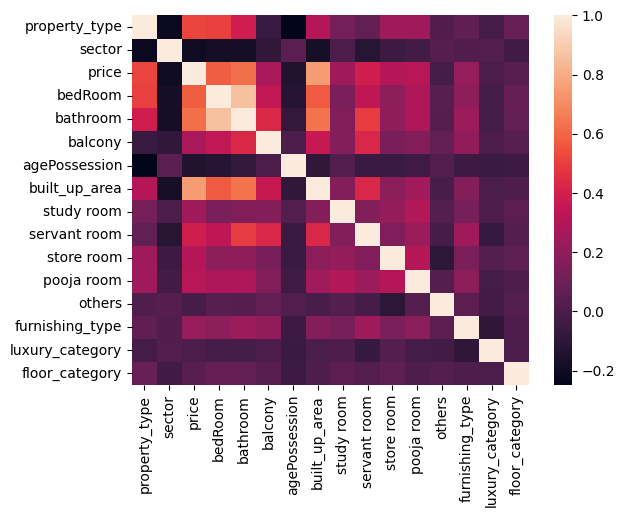

In [35]:
sns.heatmap(data_label_encoded.corr())

In [36]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,sector,-0.203058
1,price,1.000000
2,bedRoom,0.575787
3,bathroom,0.621891
4,balcony,0.270161
5,agePossession,-0.136420
6,built_up_area,0.750482
7,study room,0.239859
8,servant room,0.390716
9,store room,0.304137


In [37]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
6,built_up_area,0.649759
1,sector,0.106634
0,property_type,0.103093
3,bathroom,0.025628
2,bedRoom,0.021673
8,servant room,0.017718
5,agePossession,0.014565
4,balcony,0.011620
12,furnishing_type,0.009913
7,study room,0.009189


In [38]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
6,built_up_area,0.691048
0,property_type,0.103302
1,sector,0.101040
3,bathroom,0.035094
2,bedRoom,0.027665
8,servant room,0.022119
9,store room,0.006596
5,agePossession,0.004271
7,study room,0.004043
12,furnishing_type,0.002076


In [39]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,0.719586
1,sector,0.157988
0,property_type,0.150824
8,servant room,0.019922
3,bathroom,0.013597
2,bedRoom,0.011748
4,balcony,0.004506
9,store room,0.003074
5,agePossession,0.002777
10,pooja room,0.001733


Random Forest feature importance measures how much each feature reduces impurity across all trees during training. It is fast but can be biased toward continuous or high-cardinality features.

Permutation Importance is calculated after the model is trained by randomly shuffling one feature at a time and measuring how much the model's performance drops. A larger drop indicates a more important feature. Because it evaluates the model's actual dependence on each feature, it is more model-agnostic and often provides a more reliable estimate of feature importance.

In [40]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
6,built_up_area,1.486442
0,property_type,0.748655
3,bathroom,0.409318
9,store room,0.195351
7,study room,0.157057
12,furnishing_type,0.156875
8,servant room,0.122090
10,pooja room,0.081431
13,luxury_category,0.048935
14,floor_category,-0.000000


In [41]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
6,built_up_area,0.649860
1,sector,0.105417
0,property_type,0.104735
3,bathroom,0.025073
2,bedRoom,0.020989
8,servant room,0.017946
5,agePossession,0.014247
4,balcony,0.012645
12,furnishing_type,0.010139
7,study room,0.010011


In [42]:
# Train a linear regression model on the label-encoded and standardized training data
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
6,built_up_area,1.492493
0,property_type,0.763340
3,bathroom,0.488227
9,store room,0.198577
12,furnishing_type,0.166530
7,study room,0.164424
8,servant room,0.122105
10,pooja room,0.087113
13,luxury_category,0.060150
14,floor_category,-0.006053


In [43]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values

array([[-1.70708076e-01, -2.51117502e-01, -6.39691318e-02, ...,
        -1.65826708e-02, -2.77412669e-03, -1.12816789e-02],
       [-1.89867297e-01, -2.83303347e-01, -6.63923649e-02, ...,
        -1.22364469e-02, -5.97492662e-03, -1.05851534e-02],
       [-3.78885014e-01,  6.10983858e-01, -1.62186767e-02, ...,
        -7.16371391e-04,  6.96616068e-03, -4.32362911e-02],
       ...,
       [ 1.63896997e+00,  9.52099139e-01,  2.60670175e-01, ...,
         1.69122891e-03, -3.18400039e-02, -4.23390342e-02],
       [-4.24600541e-01, -7.07371082e-01, -2.66369072e-02, ...,
        -3.15393049e-02, -1.58178065e-02, -1.71860040e-02],
       [-1.52487305e-01, -1.46455909e-01, -4.32463672e-02, ...,
        -1.35105366e-02, -1.05952588e-03, -6.59363267e-03]],
      shape=(3655, 15))

In [44]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
6,built_up_area,1.233744
0,property_type,0.465930
1,sector,0.387486
3,bathroom,0.115506
8,servant room,0.088385
2,bedRoom,0.046025
4,balcony,0.040542
12,furnishing_type,0.028803
5,agePossession,0.027122
14,floor_category,0.025825


In [45]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [46]:
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
sector,-0.203058,0.106634,0.101040,0.157988,-0.061300,0.105417,-0.070290,0.387486
bedRoom,0.575787,0.021673,0.027665,0.011748,-0.136471,0.020989,-0.225682,0.046025
bathroom,0.621891,0.025628,0.035094,0.013597,0.409318,0.025073,0.488227,0.115506
balcony,0.270161,0.011620,0.001474,0.004506,-0.021263,0.012645,-0.040830,0.040542
agePossession,-0.136420,0.014565,0.004271,0.002777,-0.005703,0.014247,-0.014781,0.027122
built_up_area,0.750482,0.649759,0.691048,0.719586,1.486442,0.649860,1.492493,1.233744
study room,0.239859,0.009189,0.004043,0.000454,0.157057,0.010011,0.164424,0.019943
servant room,0.390716,0.017718,0.022119,0.019922,0.122090,0.017946,0.122105,0.088385
store room,0.304137,0.008175,0.006596,0.003074,0.195351,0.008022,0.198577,0.016374


In [47]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area      0.721430
sector             0.142024
bathroom           0.033310
servant room       0.025820
bedRoom            0.022725
balcony            0.010659
agePossession      0.010618
store room         0.007346
study room         0.007218
furnishing_type    0.006135
floor_category     0.005492
pooja room         0.003903
others             0.002147
luxury_category    0.001172
dtype: float64

In [48]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [49]:
scores.mean()

np.float64(0.8212055010195224)

In [50]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [51]:
scores.mean()

np.float64(0.8222683356229344)

In [52]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [53]:
export_df.to_csv(r'D:\vs code projects\rental_analysis\data\interim\Gurugram\flat_house_feature_selection.csv', index=False)

In [58]:
train_df.drop(columns=['pooja room', 'study room', 'others'],inplace=True)

In [59]:
train_df.to_csv(r'D:\vs code projects\rental_analysis\data\interim\Gurugram\flat_house_feature_selection.csv_v2', index=False)